# LFP spiking models performance with noisy inputs

We try:
- Gaussian noise to input signal (std=1)
- Gaussian noise to input signal (std=1) + random LGP phase shifts

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2025-10-30 14:02:58.314871: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 14:02:58.323661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-30 14:02:58.333116: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-30 14:02:58.336129: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-30 14:02:58.344320: I tensorflow/core/platform/cpu_feature_guar

### get the appropriate models

In [2]:
condn_phrase = 'delay400.'
condn_num = ''

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)
theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
print(f'Number of 4Hz models: {len(theta4_dirs)}')

Number of 4Hz models: 31


In [4]:
# remove the 4Hz models that did not perform well on the delay=50 task

importlib.reload(ld)

spiking_perf = []
for model_name in theta4_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)
    
# remove low-perf models from theta4_dirs
high_perf_theta4_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_theta4_dirs.append(theta4_dirs[i])
        
theta4_dirs = high_perf_theta4_dirs
print(f'New number of 4Hz models: {len(theta4_dirs)}')

New number of 4Hz models: 24


In [5]:
# for SfN, we're choosing just 20 of these models...

i_model = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
theta4_dirs = [theta4_dirs[i] for i in i_model]
print(f'Final number of 4Hz models: {len(theta4_dirs)}')

Final number of 4Hz models: 20


In [6]:
# get all of the 4Hz and 8Hz models and their performances
importlib.reload(ld)
theta4_models, theta4_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num,
                                              model_list = theta4_dirs,
                                              all_models_dir = all_models_dir)

Found 20 models with performance between -inf and inf


### compare delay 400, then +gaussiannoise1, then +gaussiannoise1phase1

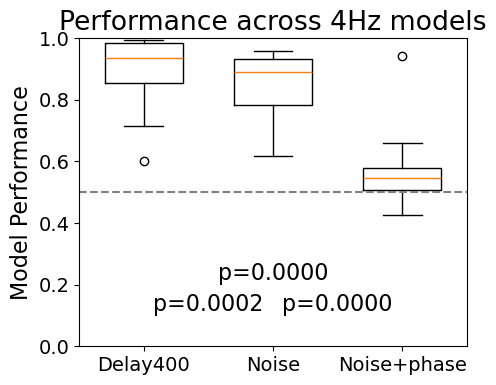

In [14]:
# boxplot comparing differences in perf across models

# set larger font sizes
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14})
plt.figure(figsize=(5,4))
perfs_400 = np.zeros(len(theta4_models))
perfs_400_noise = np.zeros(len(theta4_models))
perfs_400_phase1 = np.zeros(len(theta4_models))
for i_model, model_name in enumerate(theta4_models):
    _, trial_perfs_400 = ld.load_bhv_data(model_name, 'delay400.', all_models_dir=all_models_dir)
    _, trial_perfs_400_noise = ld.load_bhv_data(model_name, 'delay400noisegaussian1', all_models_dir=all_models_dir)
    _, trial_perfs_400_phase1 = ld.load_bhv_data(model_name, 'delay400noisegaussian1phaseshift1', all_models_dir=all_models_dir)
    perfs_400[i_model] = trial_perfs_400.mean()
    perfs_400_noise[i_model] = trial_perfs_400_noise.mean()
    perfs_400_phase1[i_model] = trial_perfs_400_phase1.mean()
data = [perfs_400, perfs_400_noise, perfs_400_phase1]
plt.boxplot(data, positions=[1, 2, 3], widths=0.6)
plt.xticks([1, 2, 3], ['Delay400', 'Noise', 'Noise+phase'])
plt.ylabel('Model Performance')
plt.title('Performance across 4Hz models')
plt.ylim(0, 1.0)

from scipy.stats import wilcoxon
stat, p = wilcoxon(perfs_400, perfs_400_noise)
plt.text(1.5, 0.1, f'p={p:.4f}', ha='center', va='bottom')
stat, p = wilcoxon(perfs_400_noise, perfs_400_phase1)
plt.text(2.5, 0.1, f'p={p:.4f}', ha='center', va='bottom')
stat, p = wilcoxon(perfs_400, perfs_400_phase1)
plt.text(2, 0.2, f'p={p:.4f}', ha='center', va='bottom')

plt.axhline(0.5, color='gray', linestyle='--')

# save as eps
plt.savefig('SfN_spikingmodel_noisyinput_perf.eps', format='eps', dpi=300)

plt.show()


### intrigued to see if amt of phase shift is related to trial performance

In [15]:
import scipy.io as sio

def load_bhv_with_phase(model_name, condn_phrase, all_models_dir):
    model_dir = os.path.join(all_models_dir, model_name)
    bhvdata_path = ld.find_files_keywords(model_dir, ['bhvdata', condn_phrase])[0]
    if bhvdata_path == []:
        print(f'No behavioral data found for {model_name} with condition {condn_phrase}{condn_num}')
        return None, None

    # Load the data
    bhv_mat = sio.loadmat(bhvdata_path)
    trial_labels = bhv_mat['all_trial_labels']
    trial_perfs = bhv_mat['all_trial_perfs'].flatten()
    trial_phaseshifts = bhv_mat['all_trial_shifts'].flatten()
    
    return trial_labels, trial_perfs, trial_phaseshifts

#### across models

In [16]:
condn_phrase = 'delay400noisegaussian1phaseshift1'

Wilcoxon signed-rank test: stat=3.0, p=9.5367431640625e-06


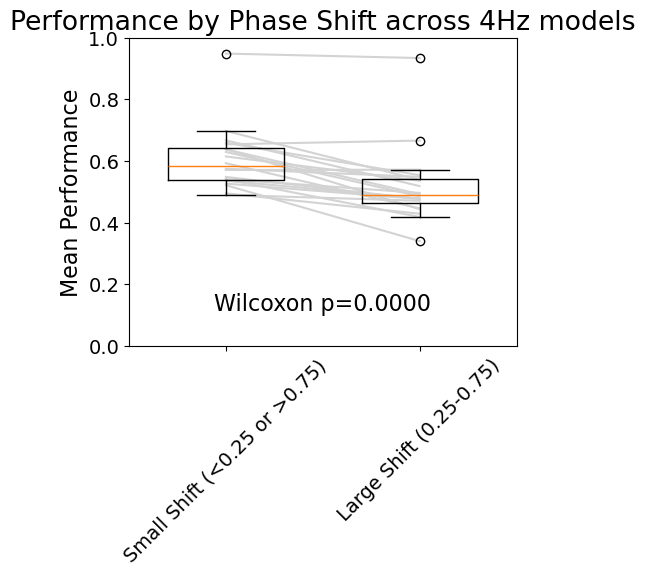

In [18]:
# loop thru models, splitting into small and large phase shifts

perfs_small = np.zeros(len(theta4_models))
perfs_large = np.zeros(len(theta4_models))

for i_model, model_name in enumerate(theta4_models):
    trial_labels, trial_perfs, trial_phaseshifts = load_bhv_with_phase(model_name, condn_phrase, all_models_dir)
    small_shift = (trial_phaseshifts < 0.25) | (trial_phaseshifts > 0.75)
    large_shift = (trial_phaseshifts >= 0.25) & (trial_phaseshifts <= 0.75)
    perfs_small[i_model] = trial_perfs[small_shift].mean()
    perfs_large[i_model] = trial_perfs[large_shift].mean()
    
data = [perfs_small, perfs_large]
plt.figure(figsize=(5,4))
plt.boxplot(data, positions=[1, 2], widths=0.6)
plt.xticks([1, 2], ['Small Shift (<0.25 or >0.75)', 'Large Shift (0.25-0.75)'], rotation=45)
plt.ylabel('Mean Performance')
plt.title(f'Performance by Phase Shift across 4Hz models')
plt.ylim(0, 1.0)

# plot light gray lines connecting paired points
for i in range(len(perfs_small)):
    plt.plot([1, 2], [perfs_small[i], perfs_large[i]], color='lightgray', zorder=0)
    
from scipy.stats import wilcoxon
stat, p = wilcoxon(perfs_small, perfs_large)
plt.text(1.5, 0.1, f'Wilcoxon p={p:.4f}', ha='center', va='bottom')

print(f'Wilcoxon signed-rank test: stat={stat}, p={p}')

# save as eps
plt.savefig('SfN_spikingmodel_phase_shift_perf.eps', format='eps', dpi=300)

plt.show()
